# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo. PREVER VALOR DO ALUGUEL.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [5]:
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [ ]:
#Sem dados faltantes. Todos os dados estão em seus respectivos tipos.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [6]:
df.describe() #VER MAX MAIOR QUE MÉDIA, LOGO TEM OUTLIER

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [ ]:
#Algumas variáveis estão com a mediana e média um pouco distantes. Como é o caso de Valor_Condomínio. Outras como Valor_Aluguel e Metragem 
#estão com valores mais próximos.

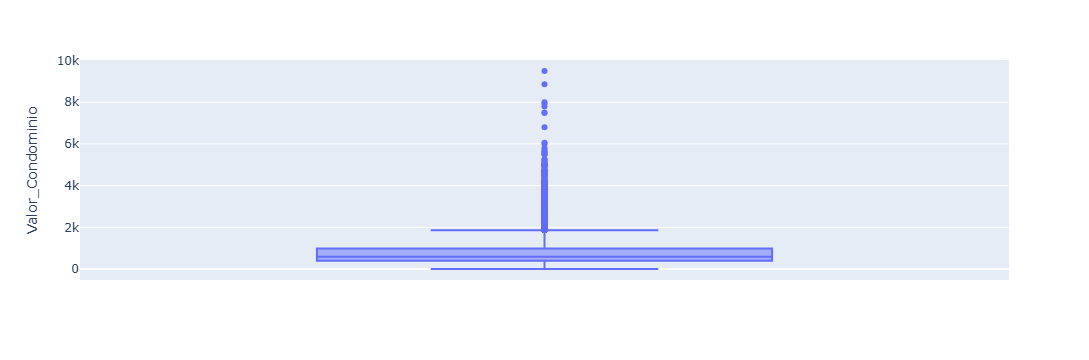

In [9]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="Valor_Condominio")
fig.show()

In [ ]:
#O gráfico mostra diversos valores acima do limite, pelas análises eles parecem ser valores reais.

In [14]:
#Cruzamento de variáveis
df.sort_values('Valor_Condominio', ascending=False)[
    ['Valor_Condominio', 'Metragem', 'Valor_Aluguel', 'N_Suites']
].head(10)

,Valor_Condominio,Metragem,Valor_Aluguel,N_Suites
6922,9500,452,10000,2
6810,8860,414,8000,4
7110,8000,452,15000,4
7119,7928,340,15000,3
7166,7800,880,19900,5
5096,7500,393,3000,4
7198,7500,627,25000,4
7109,6800,456,15000,4
4893,6059,66,2800,1
7201,6000,600,25000,4


In [ ]:
#Ao comparar com outras colunas, os dados parecem ser reias, optei por não excluí-los, só assim o modelo conseguirá fazer previsões para casos
#mais extremos. 

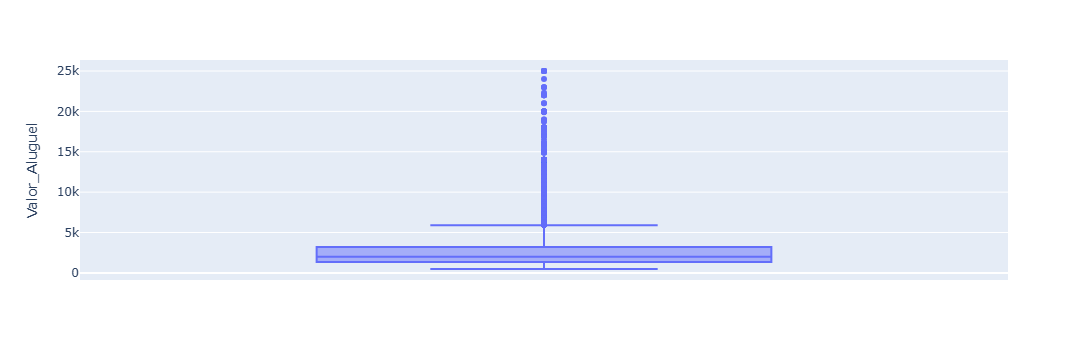

In [7]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="Valor_Aluguel")
fig.show()

In [7]:
#filtro para analise de valores raros (acima do upper fence) - Verificação se são erros. 
df_filtro = df[(df['Valor_Aluguel'] > 24000) & (df['Valor_Aluguel'] < 26000)]
df_filtro.head(50)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
7194,25000,4500,306,3,4,3,5
7195,25000,1600,209,3,4,3,3
7196,25000,3320,222,4,5,4,9
7197,25000,5636,327,4,3,2,3
7198,25000,7500,627,4,5,4,6
7199,25000,4600,364,4,2,1,0
7200,25000,3700,266,3,4,3,7
7201,25000,6000,600,4,5,4,8
7202,25000,1587,248,4,3,2,4


In [7]:
#Verificando porcentagem dos valores acima de upper fence.
print("Porcentagem de Registros onde Valor_Aluguel > 5900",
      (len(df[df['Valor_Aluguel'] > 5900]) / len(df)) * 100)

Porcentagem de Registros onde Valor_Aluguel > 5900 10.398445092322643


In [ ]:
#Esses valores foram mantidos por representarem eventos reais. Embora o upper fence seja 5.900, aproximadamente 10% da base está acima 
#desse valor, indicando uma distribuição fortemente assimétrica. Esses valores foram mantidos por representarem eventos reais.

In [6]:
#Cruzamento de variáveis
df.sort_values('Valor_Aluguel', ascending=False)[
    ['Valor_Aluguel', 'Valor_Condominio', 'Metragem', 'N_Suites']
].head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Suites,N_Quartos
7202,25000,1587,248,2,4
7201,25000,6000,600,4,4
7195,25000,1600,209,3,3
7196,25000,3320,222,4,4
7197,25000,5636,327,2,4
7200,25000,3700,266,3,3
7194,25000,4500,306,3,3
7198,25000,7500,627,4,4
7199,25000,4600,364,1,4
7193,24000,4710,364,4,4


In [ ]:
# #Substitui o valor único  de 9500 pela mediana
# mediana = df.loc[df['Valor_Condominio'] < 9000, 'Valor_Condominio'].median()
# df.loc[df['Valor_Condominio'] >= 9000, 'Valor_Condominio'] = mediana
#  #Ver valores menores e maiores
# df['Valor_Condominio'].sort_values().head(10)
# df['Valor_Condominio'].sort_values(ascending=False).head(10)

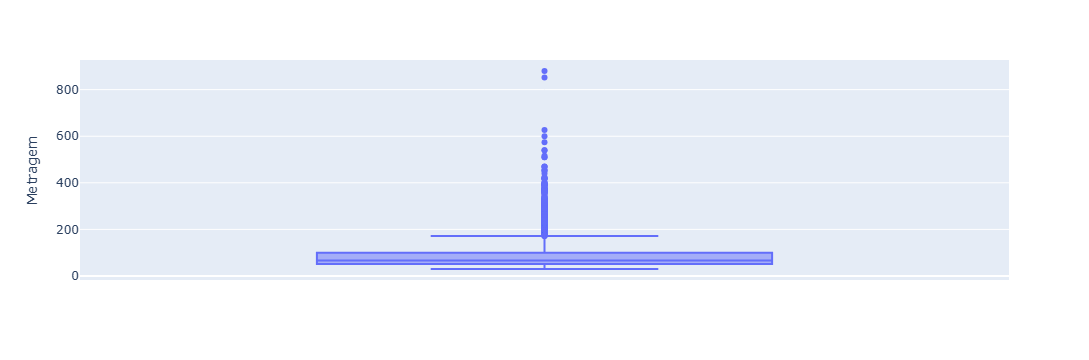

In [14]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="Metragem")
fig.show()

In [10]:
print("Porcentagem de Registros onde Metragem > 172",
      (len(df[df['Metragem'] > 172]) / len(df)) * 100)

Porcentagem de Registros onde Metragem > 172 8.982368457587118


In [18]:
#filtro para analise de valores raros (acima do upper fence) - Verificação se são erros. 
filtro = df[(df['Metragem'] > 600) & (df['Metragem'] < 900)]
filtro.head(20)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6841,8700,5040,852,7,6,5,6
7166,19900,7800,880,5,4,5,6
7198,25000,7500,627,4,5,4,6


In [ ]:
#Pelo analisado os dados acima do upper fence (172), aparentam ser dados reais. Eles compõem 8.9% da base apresentando-se como assimetria. 

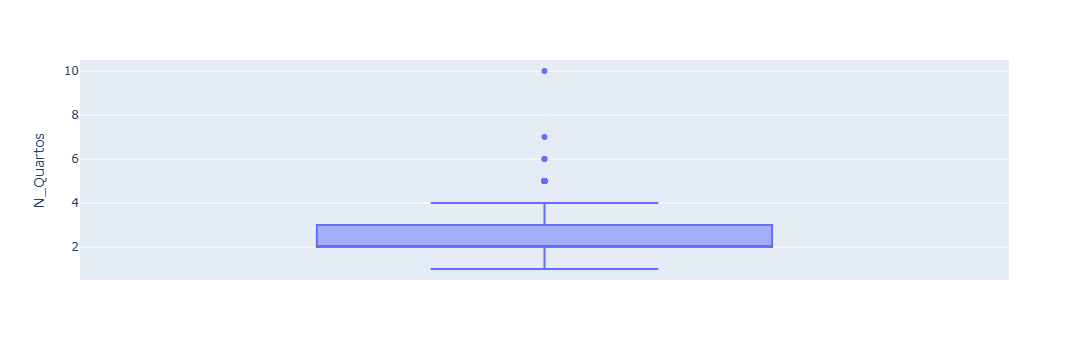

In [4]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="N_Quartos")
fig.show()

In [5]:
print("Porcentagem de Registros onde Numero Quartos > 4",
      (len(df[df['N_Quartos'] > 4]) / len(df)) * 100)

Porcentagem de Registros onde Numero Quartos > 4 0.22212966819380814


In [11]:
#Cruzamento de variáveis
df.sort_values('N_Quartos', ascending=False)[
    ['N_Quartos','N_banheiros', 'N_Suites', 'Metragem', 'Valor_Aluguel', 'Valor_Condominio']
].head(10)

,N_Quartos,N_banheiros,N_Suites,Metragem,Valor_Aluguel,Valor_Condominio
6766,10,4,1,273,8000,0
6841,7,6,5,852,8700,5040
6786,6,5,4,510,8000,4200
7082,6,8,2,400,14000,5800
6625,5,4,3,330,6700,2600
6608,5,5,4,234,6500,1550
6853,5,5,4,510,9000,4583
6597,5,5,4,234,6500,1550
7166,5,4,5,880,19900,7800
5830,5,1,4,200,4000,800


In [ ]:
# Existe um lugar com 10 quartos, mas pelo observado não parece ser erro de digitação e sim um dados real. 

In [12]:
#filtro para observar valores de zero vistos em Valor_Condominio.
filtro = df[(df['Valor_Condominio'] == 0)]
filtro.head(10)
 #RESOLVER

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
4,500,0,30,1,1,0,0
10,600,0,90,1,2,1,1
22,650,0,40,1,2,1,1
24,650,0,38,1,2,1,1
26,650,0,30,2,2,1,1
28,650,0,48,2,2,1,1
35,700,0,30,1,2,1,1
37,700,0,48,2,2,1,1


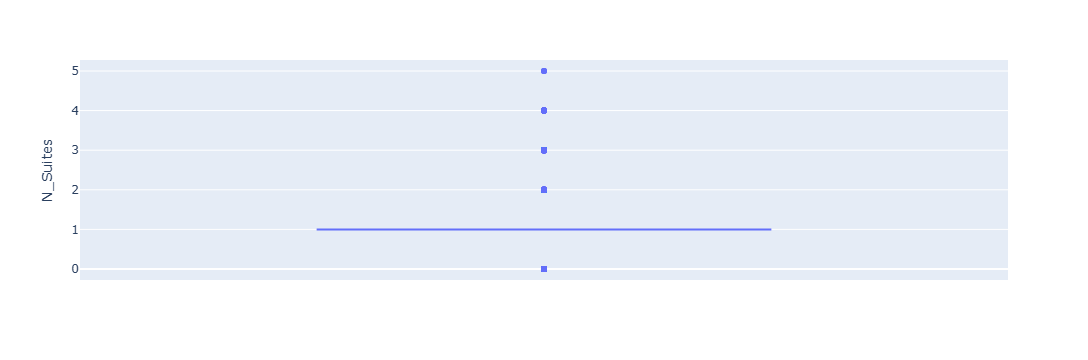

In [21]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="N_Suites")
fig.show()

In [7]:
print("Porcentagem de Registros onde N_Suites > 1",
      (len(df[df['N_Suites'] > 1]) / len(df)) * 100)

Porcentagem de Registros onde N_Suites > 1 14.091350826044705


In [ ]:
#Pelo analisado parecem dados reais apesar de raros. 

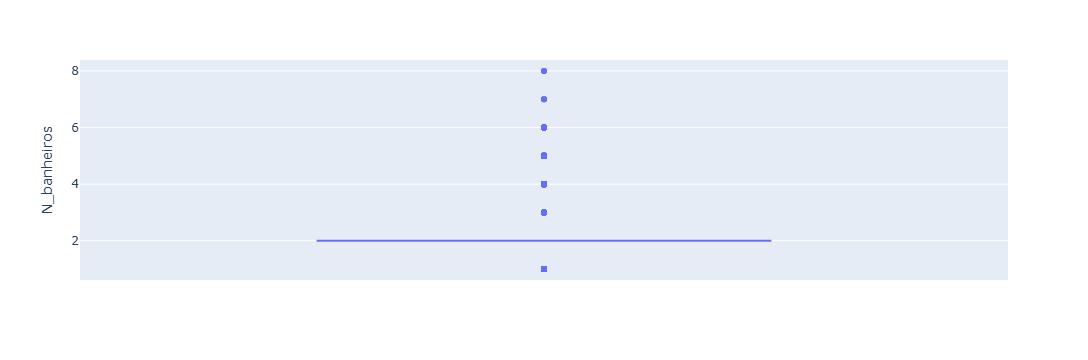

In [22]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="N_banheiros")
fig.show()

In [18]:
#Cruzamento de variáveis
df.sort_values('N_banheiros', ascending=False)[
    ['N_banheiros', 'N_Quartos', 'Metragem', 'Valor_Aluguel', 'Valor_Condominio']
].head(10)

,N_banheiros,N_Quartos,Metragem,Valor_Aluguel,Valor_Condominio
7082,8,6,400,14000,5800
6531,8,5,313,6000,0
6031,7,4,250,4500,3300
7128,7,5,370,16000,2800
5825,7,3,160,4000,1123
7065,6,4,210,14000,1800
6765,6,4,373,8000,0
6984,6,3,259,11000,3150
6803,6,4,160,8000,2640
6804,6,3,162,8000,2639


In [ ]:
#Valores parecem reais.

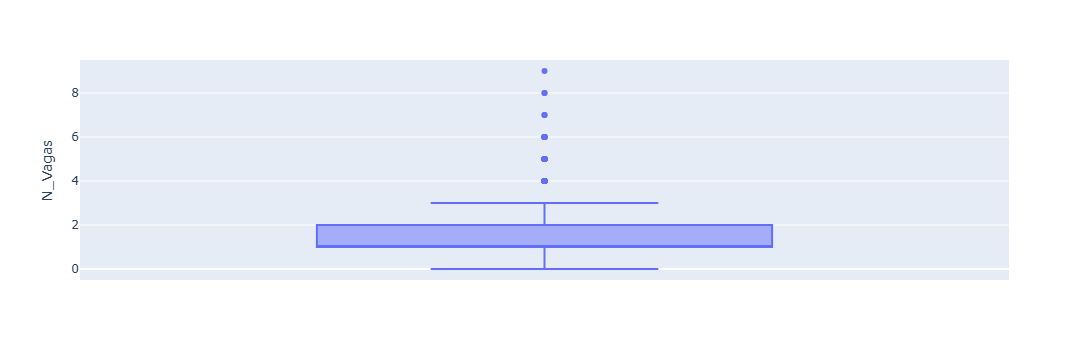

In [23]:
#BOXPLOT interativo para verificar valores discrepantes.
fig = px.box(df, y="N_Vagas")
fig.show()

In [ ]:
#Inicialmente os gráficos mostravam a presença de valores acima de upper fence, aparentemente Outliers, mas a verificação mais detalhada mostrou
#que na verdade trata-se apenas de uma distribuição assimétrica dos dados. Sim eles são dados raros, muitas vezes representando 10%, 0.2% e mesmo 14% 
#dos dados, mas preferi deixá-los pois são reias, vi outras técnicas através de pesquisas que fiz como a por LOG mas não foi ensinada no curso então
#não me senti confiante de colocar, mas vi que ela faz com que valores muito altos não distorçam os modelos, sem necessariamente excluir eles, pois
#o modelo 'entenderia' que ali há valores mais altos, mas pelo que vi depende do que se deseja analisar no código.

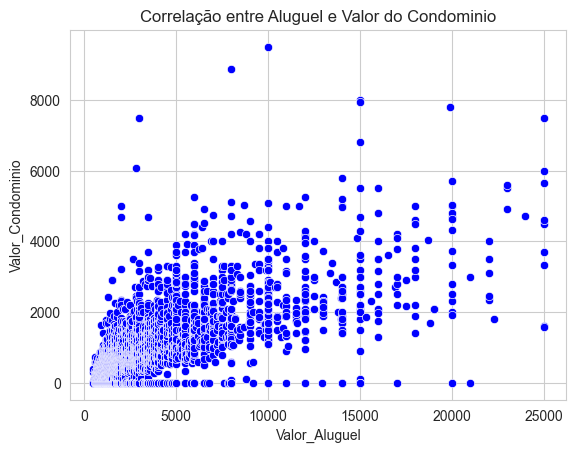

In [52]:
#Analise bivariada: Correlação entre Aluguel e Condominio.
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='Valor_Aluguel',
    y='Valor_Condominio',
    color='blue'
)

plt.title('Correlação entre Aluguel e Valor do Condominio')
plt.show()

In [ ]:
#O gráfico acima mostra a Correlação Positiva entre as variáveis Valor_Aluguel e Metragem.

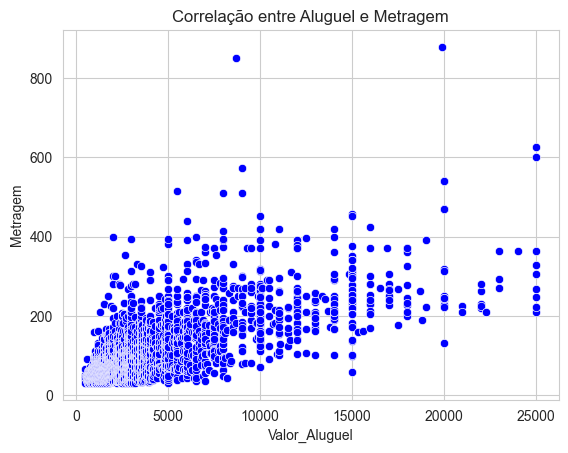

In [46]:
#Correlação.
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='Valor_Aluguel',
    y='Metragem',
    color='blue'
)

plt.title('Correlação entre Aluguel e Metragem')
plt.show()


In [ ]:
#Variáveis apresentam Correlação Positiva.

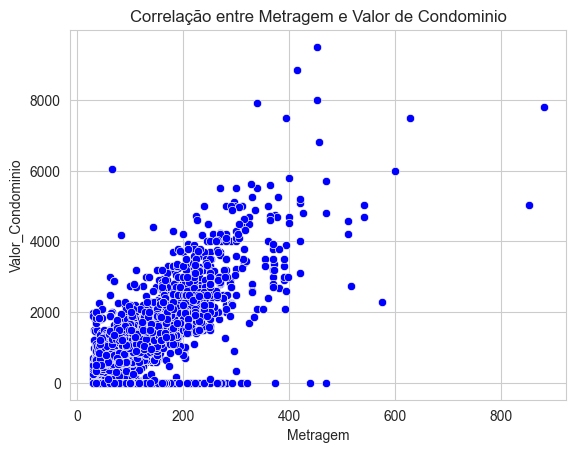

In [38]:
#Correlação  entre Metragem e Valor de Condomínio
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='Metragem',
    y='Valor_Condominio',
    color='blue'
)

plt.title('Correlação entre Metragem e Valor de Condominio')
plt.show()

In [ ]:
#Variáveis apresentam boa Correlação Positiva, aparentemente maior em relação as anteriores.

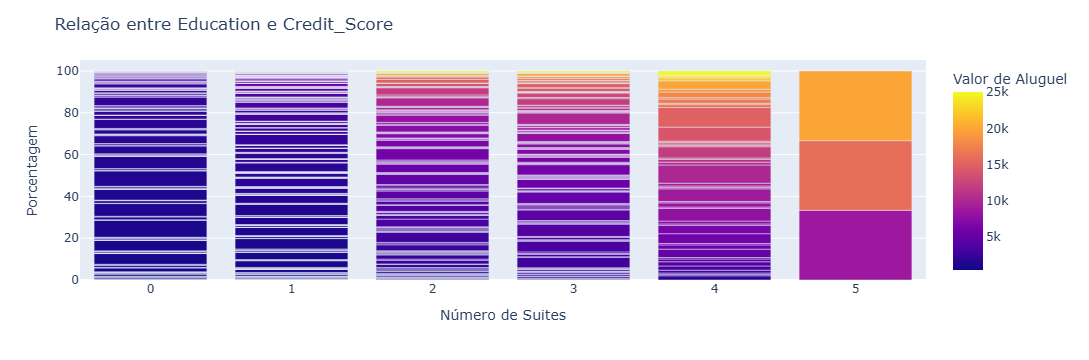

In [51]:
# Calcular a porcentagem de cada categoria
df_grouped = df.groupby(['N_Suites', 'Valor_Aluguel']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('N_Suites')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='N_Suites', y='percent', color='Valor_Aluguel', barmode='stack',
             labels={'N_Suites': 'Número de Suites', 'percent': 'Porcentagem', 'Valor_Aluguel': 'Valor de Aluguel'})

fig.update_layout(title='Relação entre Education e Credit_Score',
                  yaxis_title='Porcentagem',
                  legend_title='Credit_Score')
fig.show()

In [ ]:
#Lugares com mais quartos possuem valor de aluguel maior.

In [ ]:
#Outras variávies foram testadas e não aparentaram nenhuma correlação entre si, semelhante a este último gráfico. 

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




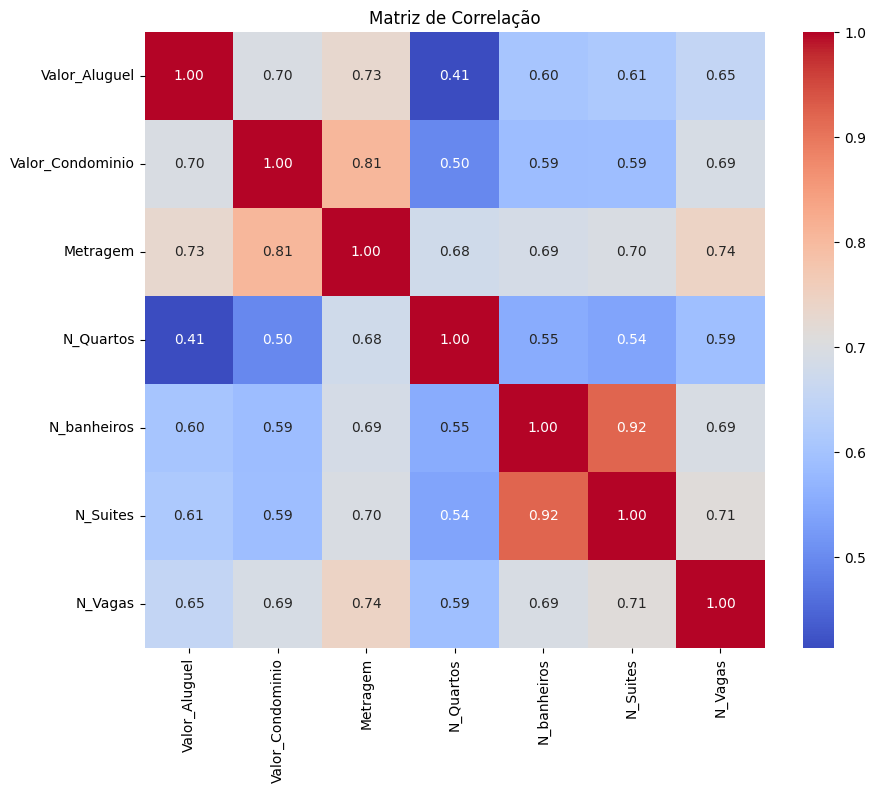

In [5]:
#Gráfico de correlação entre todas as variáveis.
corr_matriz = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
#Correlação entre todas as variáveis do DataFrame. As variáveis com relação mais fortes para 'Valor_Aluguel' são 'Valor_Condominio', 'Metragem'.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [26]:
# Separar os dados em features (X) e o alvo (y)
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

## Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
#Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
X_train

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6931,1350,176,3,4,3,3
4125,680,70,1,1,0,2
6079,650,66,2,1,0,1
5044,655,68,3,2,1,1
2299,330,33,1,1,0,1
...,...,...,...,...,...,...
3772,450,48,2,2,1,1
5191,570,34,1,1,0,1
5226,976,95,2,2,1,1
5390,550,74,3,3,1,2


In [57]:
X_test

,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
3885,484,50,2,1,0,1
4661,680,50,2,1,0,1
1038,0,58,2,2,1,1
5867,1226,127,3,1,0,2
5099,697,90,4,3,1,2
...,...,...,...,...,...,...
4689,1250,160,3,3,1,2
5313,530,43,1,2,1,1
5624,1250,147,4,4,2,3
4647,650,53,2,1,0,1


In [59]:
y_train

6931    10000
4125     2200
6079     4500
5044     2900
2299     1500
        ...  
3772     2000
5191     3000
5226     3000
5390     3200
860      1100
Name: Valor_Aluguel, Length: 5402, dtype: int64

In [58]:
y_test

3885    2100
4661    2500
1038    1200
5867    4000
5099    3000
        ... 
4689    2550
5313    3100
5624    3500
4647    2500
4453    2500
Name: Valor_Aluguel, Length: 1801, dtype: int64

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [10]:
#Separando a variável independente da variável dependente
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [11]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino.
# Esta linha cria um objeto do tipo LinearRegression(), que será usado para representar nosso modelo de regressão linear.
#Modelo com regressão linear simples
modelo1 = LinearRegression()
modelo1.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
modelo1.intercept_

np.float64(-103.17820863080169)

In [13]:
modelo1.coef_

array([34.70818769])

In [15]:
#Cálculo do R² 
modelo1.score(X, y)

0.5213271756253639

In [10]:
import numpy as np

# Aplicar log em y para reduzir impacto dos valores extremos e ver se interfere no R²
y_train_log = np.log(y)
y_test_log = np.log(y_test)

In [30]:
#Modelo com log aplicado em y
modelo2 = LinearRegression()
modelo2.fit(X, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
modelo2.intercept_

np.float64(7.014446991717432)

In [32]:
modelo2.coef_

array([0.00797353])

In [33]:
#Cálculo do R²
modelo2.score(X, y_train_log)

0.4992618666988837

In [ ]:
#O valor baixou, logo o Log não teve impacto positivo.

In [34]:
#log aplicado em X
X_train_log = np.log(X)

In [35]:
#Modelo com log em X e y
modelo3 = LinearRegression()
modelo3.fit(X_train_log, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
modelo3.intercept_

np.float64(3.634433295583401)

In [37]:
modelo3.coef_

array([0.94395262])

In [38]:
#Cálculo de R²
modelo3.score(X_train_log, y_train_log)

0.5169901402553735

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [39]:
modelo1.intercept_

np.float64(-103.17820863080169)

In [40]:
modelo1.coef_

array([34.70818769])

Nossa equação seria:  y = intercept* x + coef
Valor_Aluguel = -103.1782* (Metragem) + 34.7081

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [41]:
#Calculando R² para modelo1, sem log.
modelo1.score(X, y)

0.5213271756253639

Foram testadas transformações logarítmicas na variável dependente e em ambas as variáveis. No entanto, o modelo sem transformação apresentou maior coeficiente de determinação (R² = 0.5213271756253639). Portanto, a transformação logarítmica não melhorou o ajuste do modelo, e optou-se pela regressão linear simples sem transformação.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

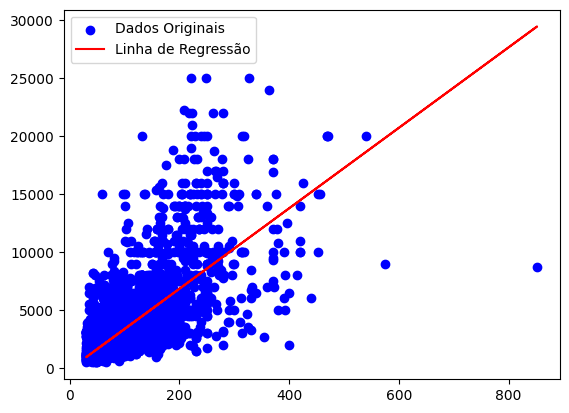

In [16]:
import matplotlib.pyplot as plt

# Plotar os dados originais
plt.scatter(X, y, color='blue', label='Dados Originais')

# Plotar a linha de regressão
plt.plot(X, modelo1.predict(X), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

In [ ]:
#A linha passa entre parte dos dados, observando-se que há dispersão, o que é explicado pelo R² = 0.5213...

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [ ]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [23]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo1.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = modelo1.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5379277457797789


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

O valor de R² para os dados de treinamento foi de: 0.5213, e para os dados de teste foi: 0.5379, sendo portanto melhor para os dados de teste, o que pode implicar que o modelo está subajustado. Ou seja, o modelo não se ajusta muito bem aos padrões dos dados.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [38]:
# Separar os dados em features (X) e o alvo (y)
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

In [39]:
#Separando treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
#Separando as variáveis independentes da variável dependente
X2 = X_train[['Valor_Condominio','Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]  # Variável independente (características)
y2 = y_train  # Variável dependente (rótulo)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [31]:
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X2,y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [33]:
modelo_multiplo.score(X2,y2)

0.5971610197647366

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [40]:
X_test = X_test[['Valor_Condominio','Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [42]:
modelo_multiplo_teste = LinearRegression()
modelo_multiplo_teste.fit(X_test, y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
modelo_multiplo_teste.score(X_test, y_test)

0.6375971027023317

In [ ]:
#Seu código aqui

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6327633459161506


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

O quadrado da Regressão Linear Simples para os dados de teste foi de 0.53, enquanto que na Múltipla foi de 0.63, isso pode ter ocorrido pois as variáveis em conjunto podem responder melhor a variável Target, tendo mais influência nela do que apenas uma única variável.